Dataset Loaded: (20, 14)

Correlation Matrix:
                avg_cost  avg_defect  spoilage_rate
avg_cost        1.00000    -0.02176       -0.02176
avg_defect     -0.02176     1.00000        1.00000
spoilage_rate  -0.02176     1.00000        1.00000

Top Spoilage Loss Vendors:
                           vendor_name  spoilage_cost
12                  hopcoms_bengaluru   6.988307e+06
6                        raichur_apmc   6.757399e+06
17                  kolar_farmers_fpo   6.696506e+06
9   sahaja_samrudha_organic_producers   6.644301e+06
4           mysore_spices_&_herbs_hub   6.628412e+06
5                  malnad_nutri_foods   6.491261e+06
8                       tapcms_hassan   6.448693e+06
0         sri_nanjundeshwara_apiaries   6.368285e+06
1             hubli_fresh_produce_co.   6.341043e+06
19    mandya_organic_farmers_alliance   6.164109e+06


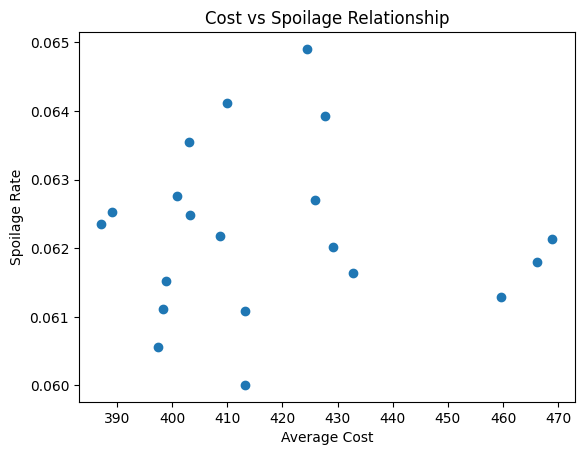

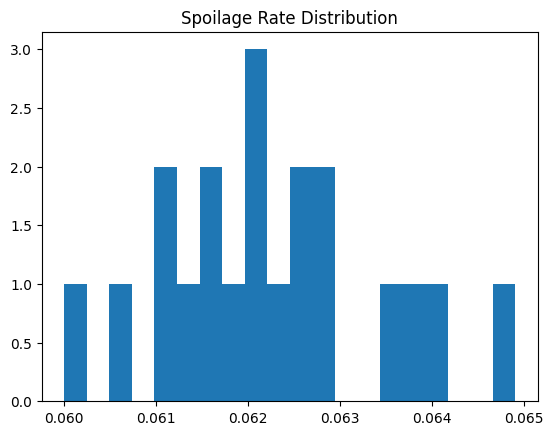


Average Spoilage Rate: 0.062234336608000006
Total Spoilage Cost: 123315379.5102978

High Spoilage Vendors: 9

Day 19 Completed Successfully


In [1]:
# ==========================================================
# DAY 19 - SPOILAGE IMPACT ANALYSIS
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

INPUT_FILE = PROJECT_ROOT / "03_processed_data/master_vendor_dataset.csv"
OUTPUT_FILE = PROJECT_ROOT / "03_processed_data/spoilage_analysis.csv"

df = pd.read_csv(INPUT_FILE)

print("Dataset Loaded:", df.shape)

# ----------------------------------------------------------
# 1. CREATE SPOILAGE METRIC (Derived)
# ----------------------------------------------------------
# Spoilage = Defective quantity (proxy)

df["spoilage_qty"] = df["total_quantity"] * (df["avg_defect"] / 100)

# Financial impact of spoilage
df["spoilage_cost"] = df["spoilage_qty"] * df["avg_cost"]

# Spoilage percentage
df["spoilage_rate"] = df["spoilage_qty"] / df["total_quantity"]

# ----------------------------------------------------------
# 2. SPOILAGE SEVERITY CLASSIFICATION
# ----------------------------------------------------------

def classify_spoilage(rate):
    if rate > df["spoilage_rate"].mean():
        return "High Spoilage"
    else:
        return "Low Spoilage"

df["spoilage_category"] = df["spoilage_rate"].apply(classify_spoilage)

# ----------------------------------------------------------
# 3. CORRELATION ANALYSIS
# ----------------------------------------------------------

correlation = df[["avg_cost", "avg_defect", "spoilage_rate"]].corr()
print("\nCorrelation Matrix:\n", correlation)

# ----------------------------------------------------------
# 4. HIGH LOSS SUPPLIERS
# ----------------------------------------------------------

high_loss = df.sort_values("spoilage_cost", ascending=False).head(10)

high_loss.to_csv(
    PROJECT_ROOT / "03_processed_data/high_spoilage_vendors.csv",
    index=False
)

print("\nTop Spoilage Loss Vendors:\n", high_loss[["vendor_name", "spoilage_cost"]])

# ----------------------------------------------------------
# 5. SPOILAGE VS COST VISUAL
# ----------------------------------------------------------

plt.figure()

plt.scatter(
    df["avg_cost"],
    df["spoilage_rate"]
)

plt.xlabel("Average Cost")
plt.ylabel("Spoilage Rate")
plt.title("Cost vs Spoilage Relationship")

plt.savefig(
    PROJECT_ROOT / "04_visualizations/cost_vs_spoilage.png"
)
plt.show()
plt.close()

# ----------------------------------------------------------
# 6. SPOILAGE DISTRIBUTION
# ----------------------------------------------------------

plt.figure()

plt.hist(df["spoilage_rate"], bins=20)

plt.title("Spoilage Rate Distribution")

plt.savefig(
    PROJECT_ROOT / "04_visualizations/spoilage_distribution.png"
)
plt.show()
plt.close()

# ----------------------------------------------------------
# 7. BUSINESS INSIGHTS (PRINT)
# ----------------------------------------------------------

print("\nAverage Spoilage Rate:", df["spoilage_rate"].mean())
print("Total Spoilage Cost:", df["spoilage_cost"].sum())

print("\nHigh Spoilage Vendors:", len(df[df["spoilage_category"] == "High Spoilage"]))

# ----------------------------------------------------------
# 8. SAVE FINAL OUTPUT
# ----------------------------------------------------------

df.to_csv(OUTPUT_FILE, index=False)

print("\nDay 19 Completed Successfully")